<a href="https://colab.research.google.com/github/mdreduanulhoque/AI_ML_Expert_with_Phitron/blob/main/Machine_Learning/ML_FINAL.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#ML FINAL EXAM

### Email: mdreduanulhoquesadik@gmail.com

Task: Copy this notebook on your drive and answer in that copy

Choose a dataset of your choice from kaggle or UCI

Some suggestions:https://www.kaggle.com/datasets/ahmettezcantekin/beginner-datasets

You may choose a dataset of your choice too

In this exam:
1. Provide code and explaination(in text cell) whenever needed and you must show the outputs
2. Before submitting run all cells and make sure the outputs are visible


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import GroupShuffleSplit
from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, make_scorer
from sklearn.metrics import classification_report

## 0. Dataset overview

Why you choose this dataset and what did you observe from the dataset description



  

https://www.kaggle.com/datasets/sadmansakib7/ecg-arrhythmia-classification-dataset

## Answer:
Two-three weeks ago, one of my faculty told me to create a model on this dataset, just for learning purpose.
The dataset describes the ECG machine's electrical signals of LEAD II and LEAD V5 in numerical ways, rather than row electrical data. It comes with the duration of our heart pump, peaks, time duration between different position of our heart and so on.

# 1. Dataset description (15 marks)


### Dataset Description
1. How many features?
2. Classification or regression problem? Why do you think so?
3. How many data points?
4. Is there any null values?
5. What kind of features are in your dataset? (Quantitative / Categorical)
6. Do you need to encode the categorical variables, why or why not?
7. Correlation of all the features, What do you understand after the correlation test?
8. Perform exploratory data analysis to extract some important relationships from your data.


Provide necessary codes and explanation

In [ ]:
df = pd.read_csv("MIT-BIH Arrhythmia Database.csv")

In [ ]:
df.columns

Index(['record', 'type', '0_pre-RR', '0_post-RR', '0_pPeak', '0_tPeak',
       '0_rPeak', '0_sPeak', '0_qPeak', '0_qrs_interval', '0_pq_interval',
       '0_qt_interval', '0_st_interval', '0_qrs_morph0', '0_qrs_morph1',
       '0_qrs_morph2', '0_qrs_morph3', '0_qrs_morph4', '1_pre-RR', '1_post-RR',
       '1_pPeak', '1_tPeak', '1_rPeak', '1_sPeak', '1_qPeak', '1_qrs_interval',
       '1_pq_interval', '1_qt_interval', '1_st_interval', '1_qrs_morph0',
       '1_qrs_morph1', '1_qrs_morph2', '1_qrs_morph3', '1_qrs_morph4'],
      dtype='str')

In [ ]:
df.shape

(100689, 34)

In [ ]:
df.isnull().sum().sum()

np.int64(0)

In [ ]:
df.dtypes

record              int64
type                  str
0_pre-RR            int64
0_post-RR         float64
0_pPeak           float64
0_tPeak           float64
0_rPeak           float64
0_sPeak           float64
0_qPeak           float64
0_qrs_interval      int64
0_pq_interval       int64
0_qt_interval       int64
0_st_interval       int64
0_qrs_morph0      float64
0_qrs_morph1      float64
0_qrs_morph2      float64
0_qrs_morph3      float64
0_qrs_morph4      float64
1_pre-RR            int64
1_post-RR         float64
1_pPeak           float64
1_tPeak           float64
1_rPeak           float64
1_sPeak           float64
1_qPeak           float64
1_qrs_interval      int64
1_pq_interval       int64
1_qt_interval       int64
1_st_interval       int64
1_qrs_morph0      float64
1_qrs_morph1      float64
1_qrs_morph2      float64
1_qrs_morph3      float64
1_qrs_morph4      float64
dtype: object

<Axes: >

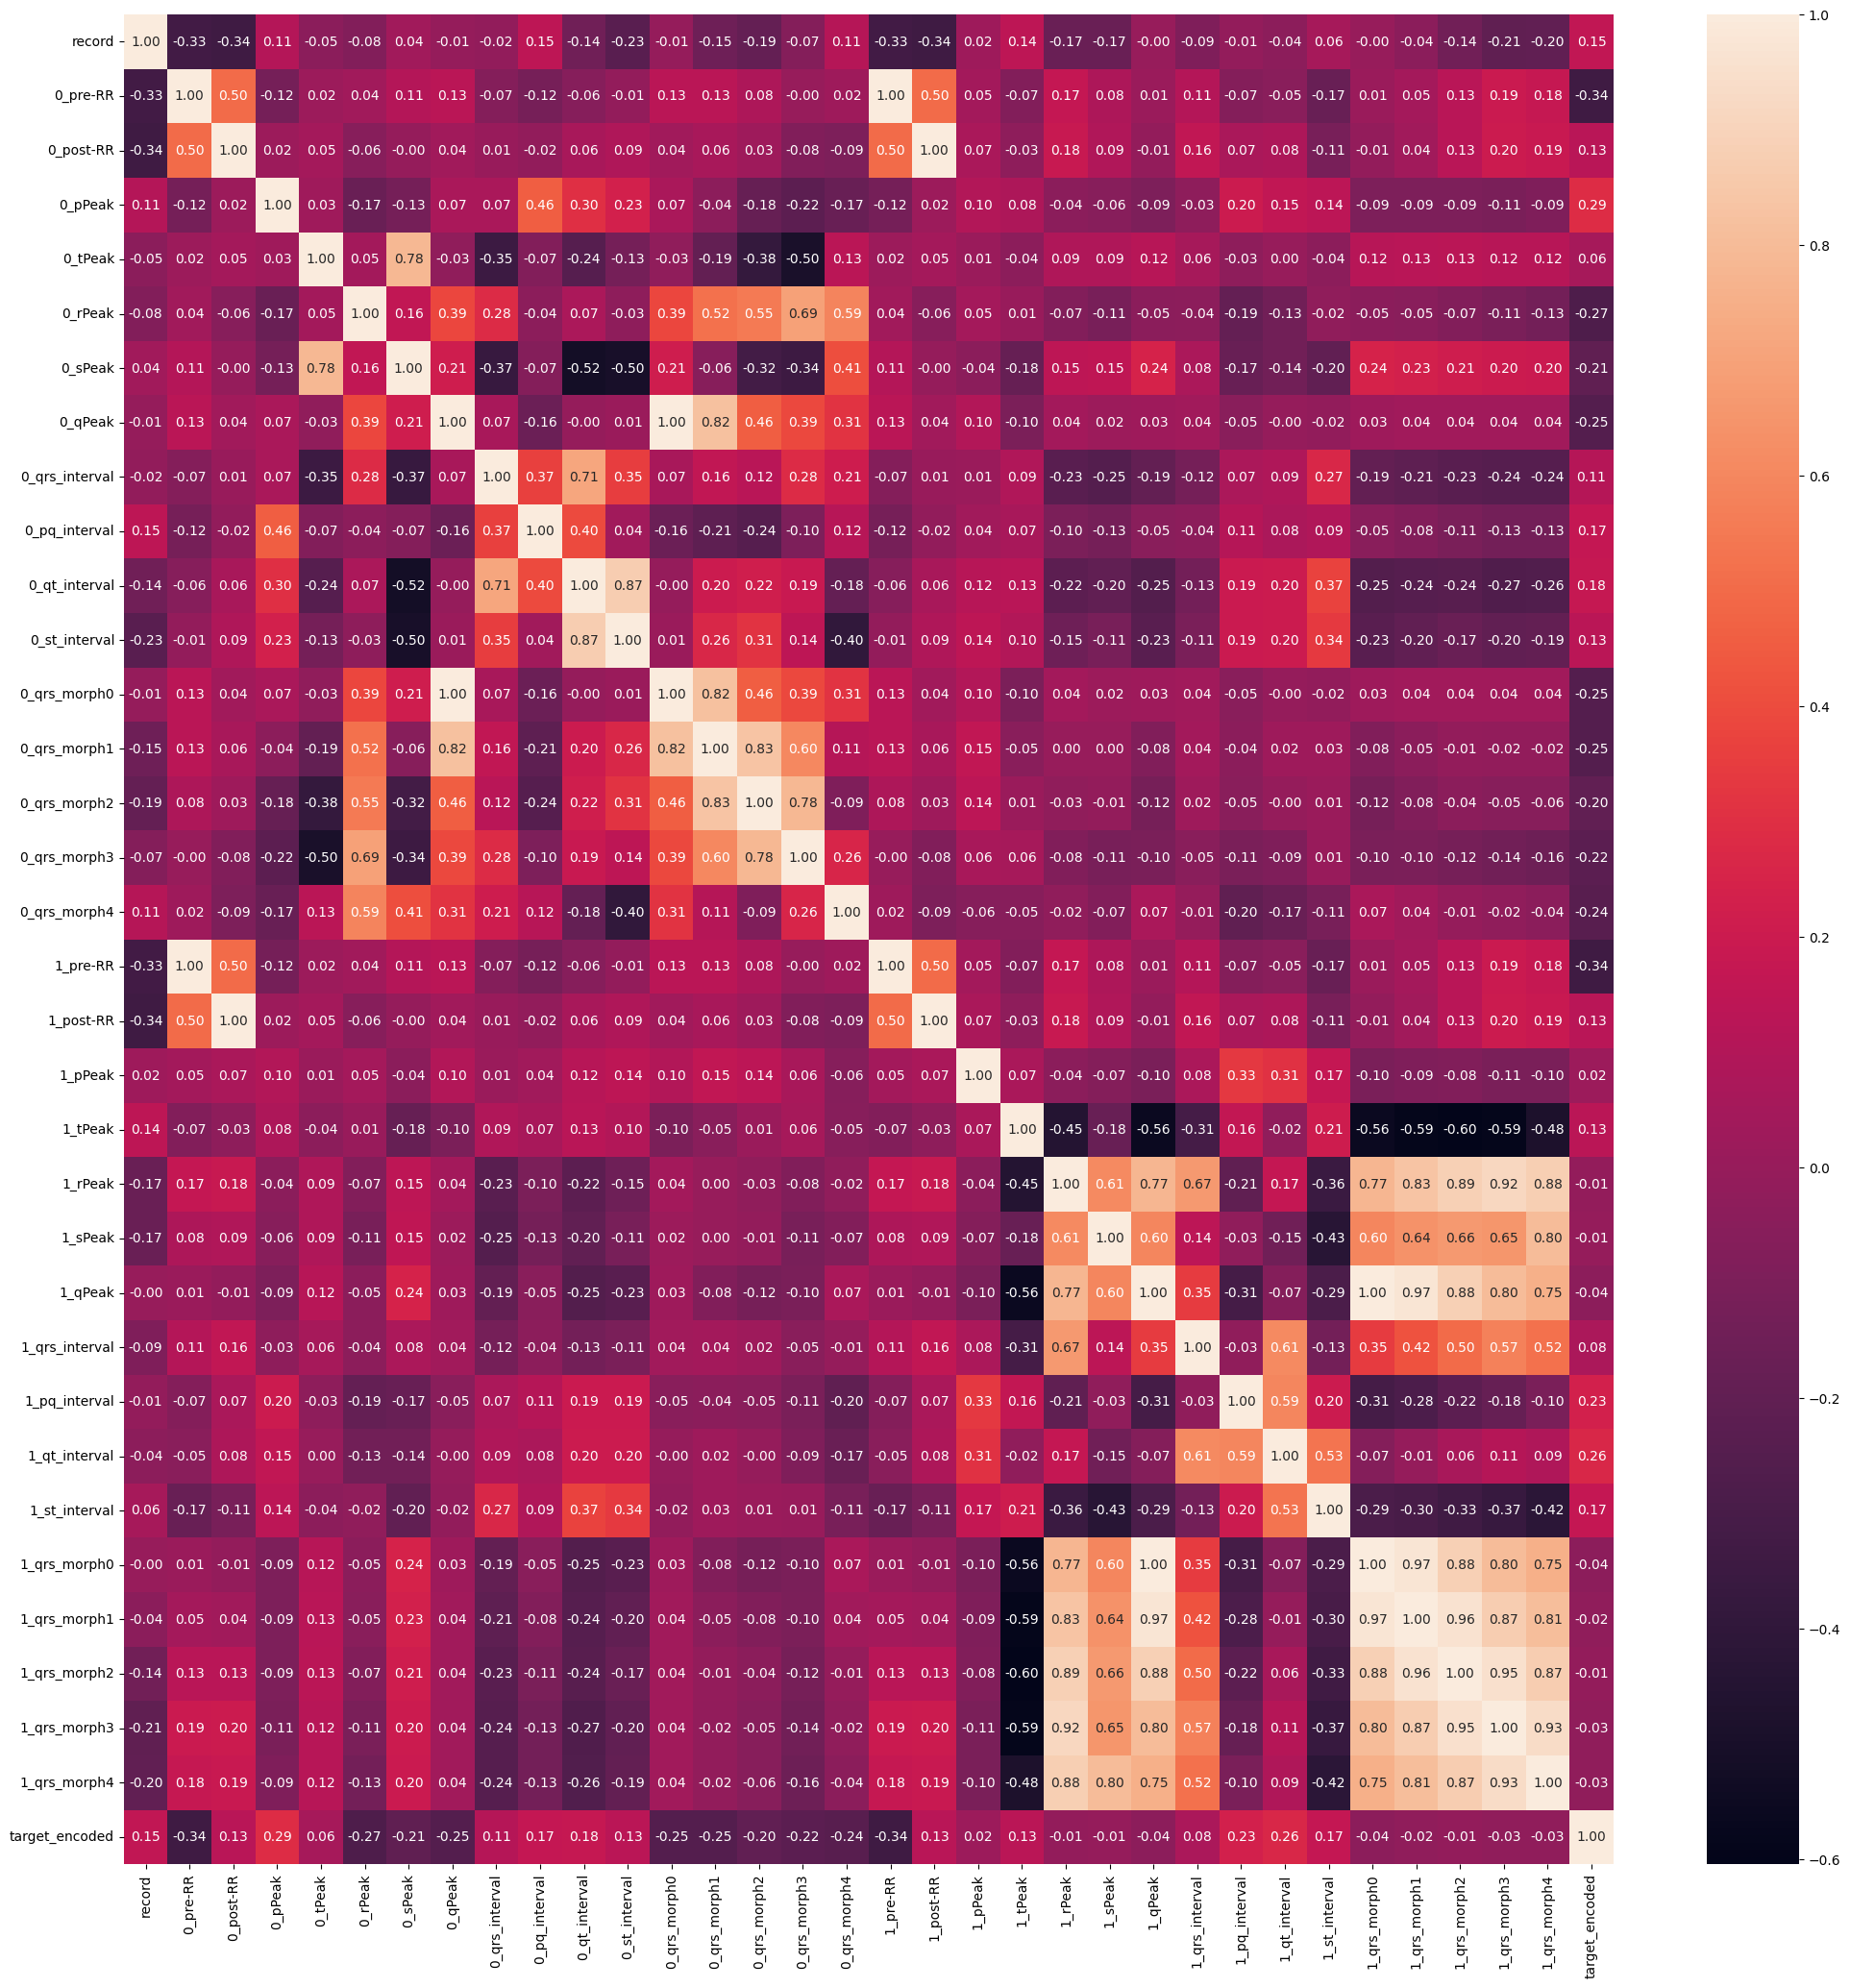

In [ ]:
le = LabelEncoder()
df['target_encoded'] = le.fit_transform(df['type'])

features = df.drop('type', axis=1)
matrix = features.corr()

plt.figure(figsize=(25, 25))
sns.heatmap(matrix, annot=True, fmt=".2f")



EDA

<Axes: >

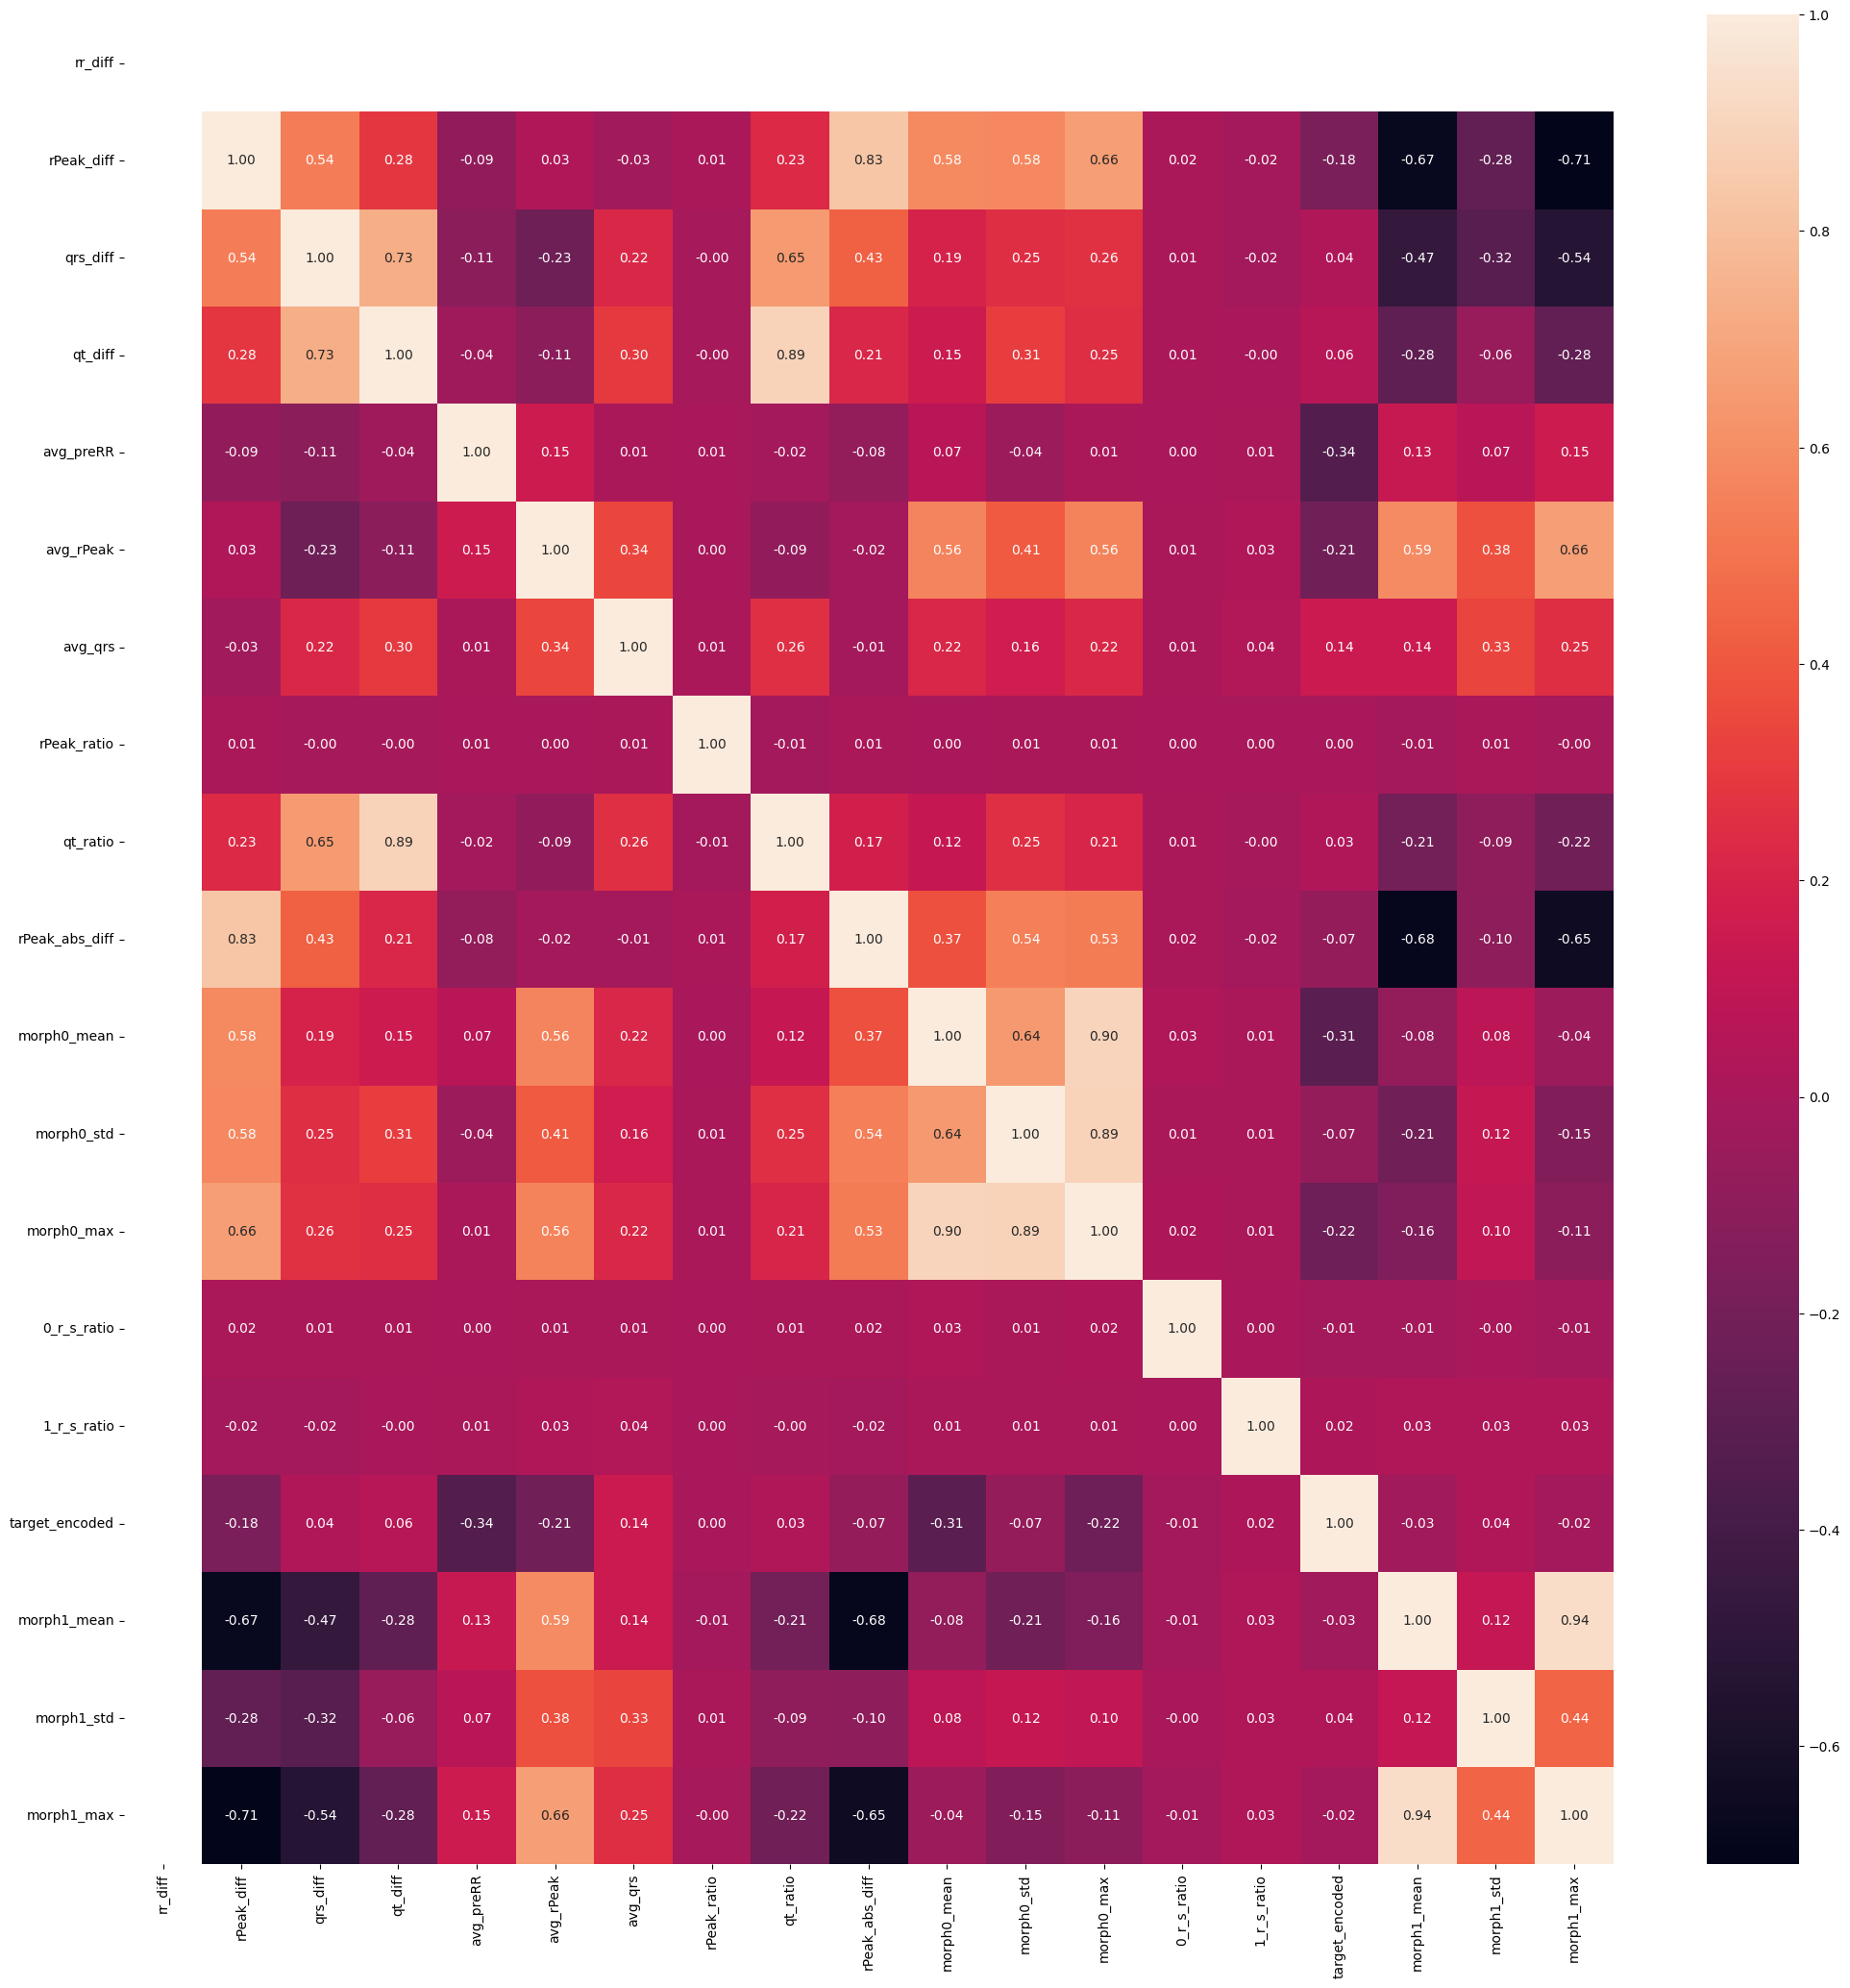

In [ ]:
df['rr_diff'] = df['0_pre-RR'] - df['1_pre-RR']
df['rPeak_diff'] = df['0_rPeak'] - df['1_rPeak']
df['qrs_diff'] = df['0_qrs_interval'] - df['1_qrs_interval']
df['qt_diff'] = df['0_qt_interval'] - df['1_qt_interval']

df['avg_preRR'] = (df['0_pre-RR'] + df['1_pre-RR']) / 2
df['avg_rPeak'] = (df['0_rPeak'] + df['1_rPeak']) / 2
df['avg_qrs'] = (df['0_qrs_interval'] + df['1_qrs_interval']) / 2

df['rPeak_ratio'] = df['0_rPeak'] / (df['1_rPeak'] + 1e-6)
df['qt_ratio'] = df['0_qt_interval'] / (df['1_qt_interval'] + 1e-6)

df['rPeak_abs_diff'] = abs(df['0_rPeak'] - df['1_rPeak'])

morph_cols_0 = ['0_qrs_morph0','0_qrs_morph1','0_qrs_morph2','0_qrs_morph3','0_qrs_morph4']
df['morph0_mean'] = df[morph_cols_0].mean(axis=1)
df['morph0_std'] = df[morph_cols_0].std(axis=1)
df['morph0_max'] = df[morph_cols_0].max(axis=1)

morph_cols_1 = ['1_qrs_morph0','1_qrs_morph1','1_qrs_morph2','1_qrs_morph3','1_qrs_morph4']
df['morph1_mean'] = df[morph_cols_1].mean(axis=1)
df['morph1_std'] = df[morph_cols_1].std(axis=1)
df['morph1_max'] = df[morph_cols_1].max(axis=1)

df['0_r_s_ratio'] = df['0_rPeak'] / (abs(df['0_sPeak']) + 1e-6)
df['1_r_s_ratio'] = df['1_rPeak'] / (abs(df['1_sPeak']) + 1e-6)

eda_df = df[['rr_diff', 'rPeak_diff', 'qrs_diff', 'qt_diff', 'avg_preRR', 'avg_rPeak', 'avg_qrs', 'rPeak_ratio', 'qt_ratio', 'rPeak_abs_diff', 'morph0_mean', 'morph0_std', 'morph0_max', '0_r_s_ratio', '1_r_s_ratio', 'target_encoded', 'morph1_mean' ,'morph1_std' ,'morph1_max']].copy()

matrix = eda_df.corr()

plt.figure(figsize=(25, 25))
sns.heatmap(matrix, annot=True, fmt=".2f")

##Answer:





1. Features: ['record', '0_pre-RR', '0_post-RR', '0_pPeak', '0_tPeak',
       '0_rPeak', '0_sPeak', '0_qPeak', '0_qrs_interval', '0_pq_interval',
       '0_qt_interval', '0_st_interval', '0_qrs_morph0', '0_qrs_morph1',
       '0_qrs_morph2', '0_qrs_morph3', '0_qrs_morph4', '1_pre-RR', '1_post-RR',
       '1_pPeak', '1_tPeak', '1_rPeak', '1_sPeak', '1_qPeak', '1_qrs_interval',
       '1_pq_interval', '1_qt_interval', '1_st_interval', '1_qrs_morph0',
       '1_qrs_morph1', '1_qrs_morph2', '1_qrs_morph3', '1_qrs_morph4']
       total: 33
  Target: ['type']

2. Classification problem, as I will try to predict the type of Arryhythmia    based on features.

3. Total datapoints: 100689

4. No null values !!

5. All features are quantitative, some are int64 and others are float64. But our target column is object.

6. I don't have any catagorical feature in my dataset. But I need to do Label Encoding for feature column.

7. There is no single feaure that impacts most, all features plays a role in predicting the target column. However, if we combine two or three same type columns together, we may find some heavey relationship.

8. I calculated difference between phases of heart beat, because row data doesn't make that much sense. Also calculated the statistical datas for Lead 0 and Lead 1 morphs. Also, encoded "type" column for heatmap plot



## 2. Dataset pre-processing (15 marks)

1. Provide code
2. Discuss the pre processing steps you applied and why?


## Answer:


   

In [ ]:
X = df.drop(columns=['type'])
y = df['type']

As we don't have any missing value we don't need to impute any values. However, we need to scale values to reduce bias towards high vlaues, we will do that in step 3, to prevent data lecage.

## 3.Feature selection and Dataset splitting (10 marks)

1. Which features you wanna keep ? Justify and drop and rest or apply any other feature engineering step
2. Perform Train test split

## Answer:



In [ ]:
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(X, y, groups=df['record']))

X_train = X.iloc[train_idx]
X_test = X.iloc[test_idx]

y_train = y.iloc[train_idx]
y_test = y.iloc[test_idx]

X_train = X_train.drop(columns=['record'])
X_test = X_test.drop(columns=['record'])

scaler = StandardScaler()
scaler.fit(X_train)
X_train = scaler.transform(X_train)
X_test = scaler.transform(X_test)

I am removing type "Q" because we have only 3 cases of it and it represents "unidentified".
Our model can't identify it due to low data frequency.

To make sure that, each record appears once in either training part or testing part, I grouped them b record, sothat model can't find a data twice in both parts.

Than I did train-test split and dropped column "record from both test and train dataset.

I fit StandardScaller on traning data and transform both train and test dataset.

## 4.  Pipeline Creation (Supervised) (10 marks)

Select 2 models of your choice and build 2 pipelines for them

## Answer:

In [ ]:
# Random Forest

random_forest_pipeline = Pipeline([
    ('random_forest', RandomForestClassifier(random_state=42))
])

random_forest_param_grid = {
    'random_forest__n_estimators': [100, 200, 300],
    'random_forest__max_depth': [None, 10, 20, 30],
    'random_forest__min_samples_split': [2, 5, 10],
    'random_forest__min_samples_leaf': [1, 2, 4],
    'random_forest__bootstrap': [True, False]
}

random_forest_grid_search = GridSearchCV(
    estimator=random_forest_pipeline,
    param_grid=random_forest_param_grid,
    cv=5,
    n_jobs=-1,
    verbose=2
)

In [ ]:
# Decision Tree
decision_tree_pipeline = Pipeline([
    ('decision_tree', DecisionTreeClassifier(random_state=42))
])

decision_tree_param_grid = {
    'decision_tree__criterion': ['gini', 'entropy'],
    'decision_tree__max_depth': [None, 5, 10, 20],
    'decision_tree__min_samples_split': [2, 5, 10],
    'decision_tree__min_samples_leaf': [1, 2, 4]
}

decision_tree_grid_search = GridSearchCV(
    estimator=decision_tree_pipeline,
    param_grid=decision_tree_param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)


# 5. Model Training (5 marks)

Train those 2 models



## Answer:

In [ ]:
random_forest_grid_search.fit(X_train, y_train)
random_forest_test_score = random_forest_grid_search.score(X_test, y_test)
random_forest_test_score

Fitting 5 folds for each of 216 candidates, totalling 1080 fits


0.9947503961965135

In [ ]:
random_forest_y_pred = random_forest_grid_search.predict(X_test)
print(classification_report(y_test, random_forest_y_pred))

              precision    recall  f1-score   support

           F       1.00      1.00      1.00        25
           N       1.00      1.00      1.00     18293
        SVEB       1.00      0.78      0.88       489
         VEB       0.93      1.00      0.96      1385

    accuracy                           0.99     20192
   macro avg       0.98      0.95      0.96     20192
weighted avg       1.00      0.99      0.99     20192



In [ ]:
decision_tree_grid_search.fit(X_train, y_train)
decision_tree_test_score = decision_tree_grid_search.score(X_test, y_test)
decision_tree_test_score

1.0

In [ ]:
decision_tree_y_pred = decision_tree_grid_search.predict(X_test)
print(classification_report(y_test, decision_tree_y_pred))

              precision    recall  f1-score   support

           F       1.00      1.00      1.00        25
           N       1.00      1.00      1.00     18293
        SVEB       1.00      1.00      1.00       489
         VEB       1.00      1.00      1.00      1385

    accuracy                           1.00     20192
   macro avg       1.00      1.00      1.00     20192
weighted avg       1.00      1.00      1.00     20192



## 6. Model selection/Comparison analysis (15 marks)
* Bar chart showcasing prediction accuracy of all models (for classification)
* Precision, recall comparison of each model. (for classification)
* Confusion Matrix (for classification)
* R2 score and Loss  (for regression)

Compare the results of all models based on all of the above described metrics. Why do you think this model performed better than the other one for this dataset?

# Answer:

Precision, Accuracy, Recall, F1 score was shown in the upper block.
But among these two, Decision Tree did well and provided accuracy of 1 in every single benchmark

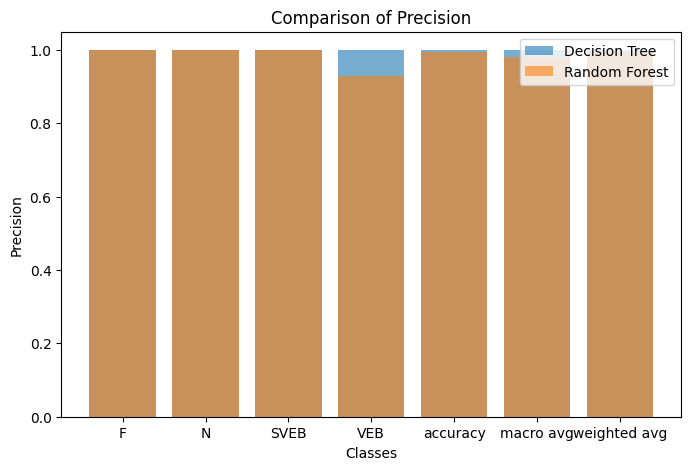

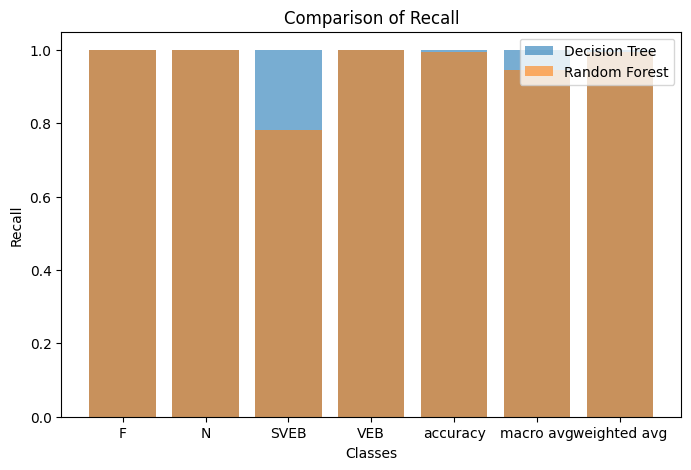

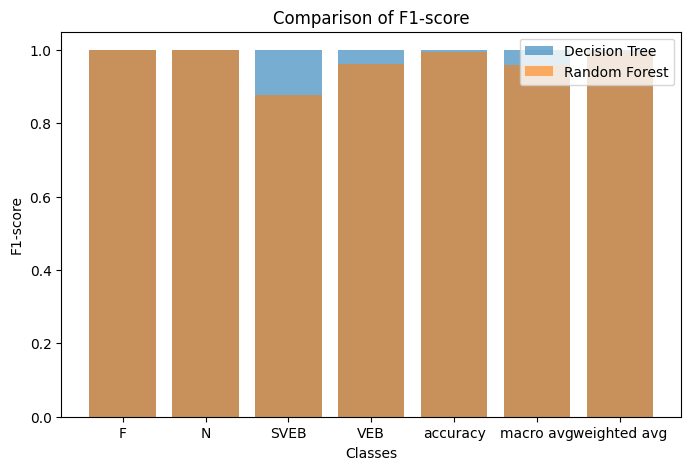

In [ ]:
decision_tree_y_pred = decision_tree_grid_search.predict(X_test)
dt_report = classification_report(y_test, decision_tree_y_pred, output_dict=True)

random_forest_y_pred = random_forest_grid_search.predict(X_test)
rf_report = classification_report(y_test, random_forest_y_pred, output_dict=True)


dt_df = pd.DataFrame(dt_report).transpose()
rf_df = pd.DataFrame(rf_report).transpose()

metrics = ['precision', 'recall', 'f1-score']

for metric in metrics:
    plt.figure(figsize=(8,5))
    plt.bar(dt_df.index, dt_df[metric], alpha=0.6, label='Decision Tree')
    plt.bar(rf_df.index, rf_df[metric], alpha=0.6, label='Random Forest')
    plt.title(f'Comparison of {metric.capitalize()}')
    plt.xlabel('Classes')
    plt.ylabel(metric.capitalize())
    plt.legend()
    plt.show()

# 7. Treating the problem as Unsupervised (20 marks) ( Explore the topic as you wish )

1. Treat the problem as a unsupervised problem and perform any unsupervised model and evalute the result
2. Which method worked better? supervised or unsupervised approach and why?

# Answer:

In [ ]:
K_Means_pipeline = Pipeline([
    ('kmeans', KMeans(random_state=42))
])

K_Means_param_grid = {
    'kmeans__n_clusters': [2, 3, 4, 5, 6, 7, 8, 9, 10],
    'kmeans__init': ['k-means++', 'random'],
    'kmeans__n_init': [10, 20]
}

silhouette_scorer = make_scorer(
    silhouette_score,
    greater_is_better=True
)

K_Means_grid_search = GridSearchCV(
    K_Means_pipeline,
    K_Means_param_grid,
    scoring=silhouette_scorer,
    cv=3,
    verbose=2
)

K_Means_grid_search.fit(X_train)

K_Means_best_model = K_Means_grid_search.best_estimator_
K_Means_labels_test = K_Means_best_model.predict(X_test)

K_Means_score_test = silhouette_score(X_test, K_Means_labels_test)
print(K_Means_score_test)

Fitting 3 folds for each of 36 candidates, totalling 108 fits


d:\C Drive\Python314\Lib\site-packages\joblib\externals\loky\backend\context.py:131: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "d:\C Drive\Python314\Lib\site-packages\joblib\externals\loky\backend\context.py", line 247, in _count_physical_cores
    cpu_count_physical = _count_physical_cores_win32()
  File "d:\C Drive\Python314\Lib\site-packages\joblib\externals\loky\backend\context.py", line 299, in _count_physical_cores_win32
    cpu_info = subprocess.run(
        "wmic CPU Get NumberOfCores /Format:csv".split(),
        capture_output=True,
        text=True,
    )
  File "d:\C Drive\Python314\Lib\subprocess.py", line 555, in run
    with Popen(*popenargs, **kwargs) as process:
         ~~~~~^^^^^^^^^^^^^^^^^^^^^^
  File "

[CV] END kmeans__init=k-means++, kmeans__n_clusters=2, kmeans__n_init=10; total time=   0.6s


d:\C Drive\Python314\Lib\site-packages\sklearn\model_selection\_validation.py:956: UserWarning: Scoring failed. The score on this train-test partition for these parameters will be set to nan. Details: 
Traceback (most recent call last):
  File "d:\C Drive\Python314\Lib\site-packages\sklearn\model_selection\_validation.py", line 943, in _score
    scores = scorer(estimator, X_test, **score_params)
  File "d:\C Drive\Python314\Lib\site-packages\sklearn\utils\validation.py", line 80, in inner_f
    return f(*args, **kwargs)
TypeError: _BaseScorer.__call__() missing 1 required positional argument: 'y_true'

  warnings.warn(


[CV] END kmeans__init=k-means++, kmeans__n_clusters=2, kmeans__n_init=10; total time=   0.2s


...

[CV] END kmeans__init=random, kmeans__n_clusters=10, kmeans__n_init=20; total time=   0.8s


d:\C Drive\Python314\Lib\site-packages\sklearn\model_selection\_validation.py:956: UserWarning: Scoring failed. The score on this train-test partition for these parameters will be set to nan. Details: 
Traceback (most recent call last):
  File "d:\C Drive\Python314\Lib\site-packages\sklearn\model_selection\_validation.py", line 943, in _score
    scores = scorer(estimator, X_test, **score_params)
  File "d:\C Drive\Python314\Lib\site-packages\sklearn\utils\validation.py", line 80, in inner_f
    return f(*args, **kwargs)
TypeError: _BaseScorer.__call__() missing 1 required positional argument: 'y_true'

  warnings.warn(


[CV] END kmeans__init=random, kmeans__n_clusters=10, kmeans__n_init=20; total time=   0.9s


d:\C Drive\Python314\Lib\site-packages\sklearn\model_selection\_validation.py:956: UserWarning: Scoring failed. The score on this train-test partition for these parameters will be set to nan. Details: 
Traceback (most recent call last):
  File "d:\C Drive\Python314\Lib\site-packages\sklearn\model_selection\_validation.py", line 943, in _score
    scores = scorer(estimator, X_test, **score_params)
  File "d:\C Drive\Python314\Lib\site-packages\sklearn\utils\validation.py", line 80, in inner_f
    return f(*args, **kwargs)
TypeError: _BaseScorer.__call__() missing 1 required positional argument: 'y_true'

  warnings.warn(
d:\C Drive\Python314\Lib\site-packages\sklearn\model_selection\_search.py:1234: UserWarning: One or more of the test scores are non-finite: [nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan]
  warnings.warn(


[CV] END kmeans__init=random, kmeans__n_clusters=10, kmeans__n_init=20; total time=   0.8s
0.24004369668616538


When I treated the problem as unsupervised, all the model did it's worse.
Conclusion: This is a supervised classification problem.

## 8. Self Reflection on this machine learning course (10 marks)

Explain the hardest and the easiest topic of this course according to you in a intuitive way (you may also provide real world implementation , necessity etc along with the explaination)

##Answer:

Easiest Topic: Logical Regression
Fun to Learn: Randon Forest
Hardest Topic: PCA

I loved random forest and decision tree as well. I can connect both of them in real life and use their decision making process in real life too.